0. Objectif de l'EDA

1. Chargement des données

2. Vue d'ensemble du dataset

3. Analyse de la demande

4. Analyse des collectes

5. Analyse des stocks

6. Analyse par région

7. Analyse par groupe sanguin

8. Analyse temporelle

9. Premiers enseignements métier

# Analyse exploratoire des données (EDA)

## Objectif

L'objectif de cette analyse est de comprendre les caractéristiques du jeu de données simulé afin d'identifier les principaux facteurs pouvant influencer les besoins en produits sanguins.

Cette étape permettra notamment :

- de comprendre les tendances historiques ;
- d'identifier les régions les plus consommatrices ;
- d'étudier les groupes sanguins les plus sollicités ;
- d'observer la relation entre demande, collecte et stock ;
- de préparer la phase de modélisation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = r"C:\Users\henri-philippe.konan\Desktop\Perso\Devenir data scientist\Portfolio repo Github\CNTS_forecasting_poc\cnts_simulated_blood_demand.csv"
df = pd.read_csv(data)

df.head()

,month,region,blood_group,hospital_demand_units,collected_units,available_stock_units,expired_units,season,shortage_flag,coverage_ratio,risk_level
0,2023-01,Abidjan,O+,532,527,693,7,fêtes/accidents,0,1.30,Faible
1,2023-01,Abidjan,A+,347,358,422,4,fêtes/accidents,0,1.22,Faible
2,2023-01,Abidjan,B+,271,257,286,5,fêtes/accidents,0,1.06,Faible
3,2023-01,Abidjan,AB+,91,68,86,2,fêtes/accidents,1,0.95,Moyen
4,2023-01,Abidjan,O-,59,46,51,1,fêtes/accidents,1,0.86,Moyen


In [2]:
df.describe(include="all")

,month,region,blood_group,hospital_demand_units,collected_units,available_stock_units,expired_units,season,shortage_flag,coverage_ratio,risk_level
count,1440,1440,1440,1440.000000,1440.000000,1440.000000,1440.000000,1440,1440.000000,1440.000000,1440
unique,36,5,8,NaN,NaN,NaN,NaN,3,NaN,NaN,3
top,2023-01,Abidjan,O+,NaN,NaN,NaN,NaN,normal,NaN,NaN,Élevé
freq,40,288,180,NaN,NaN,NaN,NaN,600,NaN,NaN,899
mean,NaN,NaN,NaN,75.404167,62.496528,72.855556,1.399306,NaN,0.817361,0.783083,NaN
std,NaN,NaN,NaN,112.851827,103.047140,125.575705,2.803180,NaN,0.386504,0.212117,NaN
min,NaN,NaN,NaN,2.000000,1.000000,1.000000,0.000000,NaN,0.000000,0.250000,NaN
25%,NaN,NaN,NaN,13.000000,7.000000,8.000000,0.000000,NaN,1.000000,0.620000,NaN
50%,NaN,NaN,NaN,27.000000,21.000000,23.000000,0.000000,NaN,1.000000,0.750000,NaN
75%,NaN,NaN,NaN,89.000000,73.000000,82.000000,2.000000,NaN,1.000000,0.940000,NaN


In [3]:
df.dtypes

month                     object
region                    object
blood_group               object
hospital_demand_units      int64
collected_units            int64
available_stock_units      int64
expired_units              int64
season                    object
shortage_flag              int64
coverage_ratio           float64
risk_level                object
dtype: object

In [4]:
df.nunique()

month                     36
region                     5
blood_group                8
hospital_demand_units    275
collected_units          254
available_stock_units    269
expired_units             23
season                     3
shortage_flag              2
coverage_ratio           102
risk_level                 3
dtype: int64

In [5]:
df.isna().sum()

month                    0
region                   0
blood_group              0
hospital_demand_units    0
collected_units          0
available_stock_units    0
expired_units            0
season                   0
shortage_flag            0
coverage_ratio           0
risk_level               0
dtype: int64

Le jeu de données est complet et ne contient aucune valeur manquante. Les catégories sont correctement réparties entre régions et groupes sanguins. Toutefois, certaines variables apparaissent très homogènes, ce qui constitue une limite du jeu de données simulé.

## Quel est le niveau de demande observé ?

In [10]:
df["hospital_demand_units"].describe()

count    1440.000000
mean       75.404167
std       112.851827
min         2.000000
25%        13.000000
50%        27.000000
75%        89.000000
max       697.000000
Name: hospital_demand_units, dtype: float64

In [11]:
df["hospital_demand_units"].sum()

108582

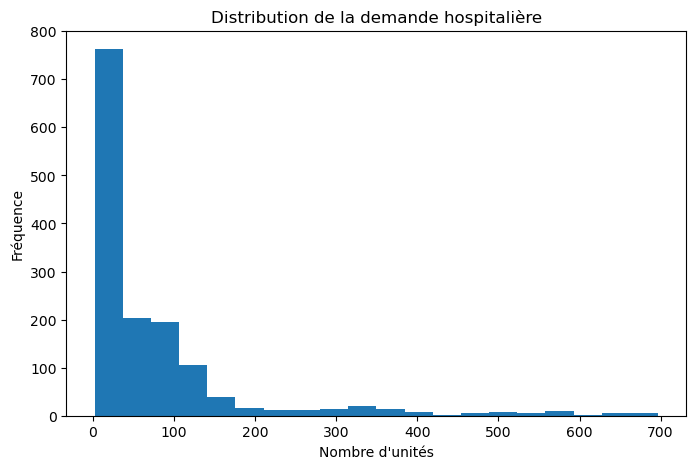

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["hospital_demand_units"], bins=20)

plt.title("Distribution de la demande hospitalière")

plt.xlabel("Nombre d'unités")

plt.ylabel("Fréquence")

plt.show()

Quelles régions et quels groupes sanguins génèrent les plus fortes demandes ?

In [13]:
df.sort_values(
    by="hospital_demand_units",
    ascending=False
).head(20)

,month,region,blood_group,hospital_demand_units,collected_units,available_stock_units,expired_units,season,shortage_flag,coverage_ratio,risk_level
1160,2025-06,Abidjan,O+,697,567,717,17,paludisme,0,1.03,Moyen
1400,2025-12,Abidjan,O+,689,683,758,22,fêtes/accidents,0,1.10,Faible
1240,2025-08,Abidjan,O+,677,525,731,16,paludisme,0,1.08,Faible
680,2024-06,Abidjan,O+,670,694,847,23,paludisme,0,1.26,Faible
280,2023-08,Abidjan,O+,668,484,589,20,paludisme,1,0.88,Moyen
1200,2025-07,Abidjan,O+,662,615,759,5,paludisme,0,1.15,Faible
1280,2025-09,Abidjan,O+,650,524,585,12,paludisme,1,0.90,Moyen
1320,2025-10,Abidjan,O+,649,516,671,6,paludisme,0,1.03,Moyen
360,2023-10,Abidjan,O+,648,673,801,26,paludisme,0,1.24,Faible
920,2024-12,Abidjan,O+,629,503,624,14,fêtes/accidents,1,0.99,Moyen


In [14]:
df.groupby("region")["hospital_demand_units"].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Abidjan,288.0,190.354167,193.317596,13.0,48.75,78.0,327.00,697.0
Bouaké,288.0,63.736111,64.953158,4.0,16.00,26.5,109.00,247.0
Korhogo,288.0,36.097222,36.671595,2.0,9.00,14.5,62.00,174.0
San Pedro,288.0,41.590278,42.246483,3.0,11.00,17.0,72.25,157.0
Yamoussoukro,288.0,45.243056,46.132327,3.0,11.75,19.0,77.00,179.0


In [15]:
df.groupby("blood_group")["hospital_demand_units"].describe()

,count,mean,std,min,25%,50%,75%,max
blood_group,,,,,,,,
A+,180.0,144.300000,114.091892,53.0,74.75,91.0,130.25,473.0
A-,180.0,23.277778,18.386616,8.0,12.00,15.0,22.00,83.0
AB+,180.0,35.838889,28.364776,14.0,19.00,22.0,33.00,117.0
AB-,180.0,6.600000,5.250805,2.0,3.00,4.0,6.00,21.0
B+,180.0,121.144444,96.531705,46.0,63.00,75.5,108.50,414.0
B-,180.0,16.477778,12.979767,6.0,9.00,10.0,15.25,55.0
O+,180.0,229.022222,180.835984,77.0,119.75,146.0,213.75,697.0
O-,180.0,26.572222,21.041600,9.0,14.00,17.0,25.25,87.0
